In [1]:
import pandas as pd
import numpy as np

# checking how many columns does the file have
#df_train = pd.read_csv("../data/raw/train_FD001.txt", sep=r"\s+", header=None)
#print(df_train.shape)


# loading train data
train_file = "../data/raw/train_FD001.txt"
df_train = pd.read_csv(train_file, sep=r"\s+", header=None)

# assigning column names
columns = ['unit_number', 'time_in_cycles', 'operational_setting_1',
           'operational_setting_2', 'operational_setting_3']
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
columns += sensor_cols
df_train.columns = columns

# inspection
print("Train shape:", df_train.shape)
print(df_train.head())
print(df_train['unit_number'].nunique(), "engines in train set")


# computing RUL (Remaining Useful Life) for training data
# max cycles per engine
max_cycles = df_train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

# merge max cycle info
df_train = df_train.merge(max_cycles, on='unit_number', how='left')

# RUL = max_cycle - current cycle
df_train['RUL'] = df_train['max_cycle'] - df_train['time_in_cycles']

# inspection
print(df_train[['unit_number', 'time_in_cycles', 'RUL']].head())



# distribution of RUL
print(df_train['RUL'].describe())

# sample for one engine
engine1 = df_train[df_train['unit_number'] == 1]
print(engine1.head())

Train shape: (20631, 26)
   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_measurement_1  sensor_measurement_2  \
0                  100.0                518.67                641.82   
1                  100.0                518.67                642.15   
2                  100.0                518.67                642.35   
3                  100.0                518.67                642.35   
4                  100.0                518.67                642.37   

   sensor_measurement_3  sensor_measurement_4  sensor_measure

In [2]:
# Temporal Feature Engineering

# sensors to use for rolling features
rolling_sensors = [
    'sensor_measurement_2',
    'sensor_measurement_3',
    'sensor_measurement_4',
    'sensor_measurement_7',
    'sensor_measurement_11'
]

window_size = 5

# sorting properly
df_train = df_train.sort_values(['unit_number', 'time_in_cycles'])

# adding delta features
def rolling_slope(series):
    x = np.arange(len(series))
    if len(series) < 2:
        return 0.0
    return np.polyfit(x, series, 1)[0]


# creating rolling features per engine
for sensor in rolling_sensors:
    df_train[f'{sensor}_roll_mean'] = (
        df_train
        .groupby('unit_number')[sensor]
        .rolling(window=window_size)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df_train[f'{sensor}_roll_std'] = (
        df_train
        .groupby('unit_number')[sensor]
        .rolling(window=window_size)
        .std()
        .reset_index(level=0, drop=True)
    )

# adding slope features
for sensor in rolling_sensors:
    df_train[f'{sensor}_roll_slope'] = (
        df_train
        .groupby('unit_number')[sensor]
        .rolling(window=window_size)
        .apply(rolling_slope, raw=False)
        .reset_index(level=0, drop=True)
    )


# adding delta features
for sensor in rolling_sensors:
    df_train[f'{sensor}_delta'] = (
        df_train
        .groupby('unit_number')[sensor]
        .diff()
    )


# dropping rows with NaNs caused by rolling window
df_train = df_train.dropna().reset_index(drop=True)

print(df_train.filter(like='roll_slope').describe())
print("Train shape after rolling features:", df_train.shape)

       sensor_measurement_2_roll_slope  sensor_measurement_3_roll_slope  \
count                     20231.000000                     20231.000000   
mean                          0.006435                         0.074929   
std                           0.096441                         1.265559   
min                          -0.387000                        -4.917000   
25%                          -0.058000                        -0.788500   
50%                           0.006000                         0.071000   
75%                           0.071000                         0.938000   
max                           0.347000                         5.324000   

       sensor_measurement_4_roll_slope  sensor_measurement_7_roll_slope  \
count                     20231.000000                     20231.000000   
mean                          0.132044                        -0.012416   
std                           1.271458                         0.128570   
min                     

Feature shape: (20231, 45)
Target shape: (20231,)
Missing values per column:
 time_in_cycles                      0
operational_setting_1               0
operational_setting_2               0
operational_setting_3               0
sensor_measurement_1                0
sensor_measurement_2                0
sensor_measurement_3                0
sensor_measurement_4                0
sensor_measurement_5                0
sensor_measurement_6                0
sensor_measurement_7                0
sensor_measurement_8                0
sensor_measurement_9                0
sensor_measurement_10               0
sensor_measurement_11               0
sensor_measurement_12               0
sensor_measurement_13               0
sensor_measurement_14               0
sensor_measurement_15               0
sensor_measurement_16               0
sensor_measurement_17               0
sensor_measurement_18               0
sensor_measurement_19               0
sensor_measurement_20               0
sensor_mea

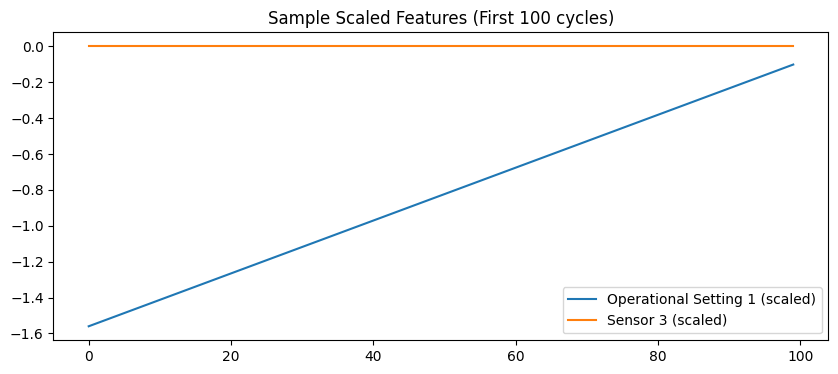

In [3]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# separate features and target
# features: operational settings + sensors
feature_cols = ['time_in_cycles',
                'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
               [f'sensor_measurement_{i}' for i in range(1, 22)] + \
               [f'{s}_roll_mean' for s in rolling_sensors] + \
               [f'{s}_roll_std' for s in rolling_sensors]

# adding slopes to feature list
feature_cols += [f'{s}_roll_slope' for s in rolling_sensors]
feature_cols += [f'{s}_delta' for s in rolling_sensors]

X = df_train[feature_cols]

max_rul = 125
df_train['RUL_capped'] = df_train['RUL'].clip(upper=max_rul)  # add a new column for clarity
y = df_train['RUL_capped']  # use capped RUL as target

#y = df_train['RUL']


print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# handling missing values
print("Missing values per column:\n", X.isnull().sum())

# if there are any missing, fill with median
X = X.fillna(X.median())

# scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)

#  quick visualization of scaled features

plt.figure(figsize=(10,4))
plt.plot(X_scaled[:100, 0], label='Operational Setting 1 (scaled)')
plt.plot(X_scaled[:100, 3], label='Sensor 3 (scaled)')
plt.legend()
plt.title("Sample Scaled Features (First 100 cycles)")
plt.show()

# save preprocessed data
np.save("../data/preprocessed/X_train_scaled.npy", X_scaled)
np.save("../data/preprocessed/y_train.npy", y.values)

X_train shape: (16241, 45)
X_val shape: (3990, 45)
Baseline Model Metrics:
RMSE: 15.54
MAE:  10.44
R²:   0.86


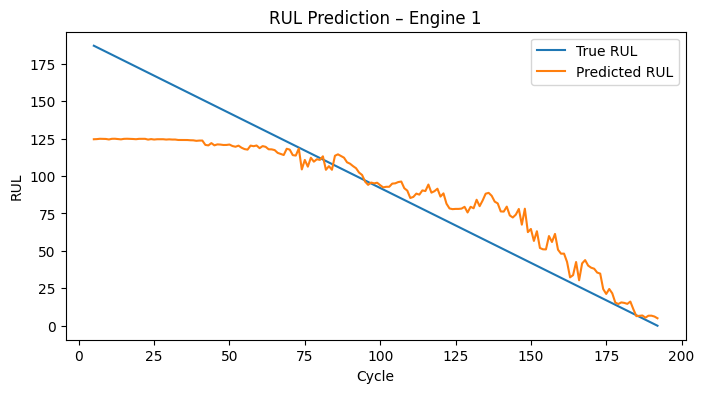

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

groups = df_train['unit_number'].values

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X_scaled, y, groups))

X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
y_train, y_val = y.values[train_idx], y.values[val_idx]

# train/test split (local validation)
#X_train, X_val, y_train, y_val = train_test_split(
#    X_scaled, y.values, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,  # number of trees
    max_depth=10,      # limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# predictions
y_pred = rf.predict(X_val)

# evaluation metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Baseline Model Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

# picked one validation engine
val_units = df_train.iloc[val_idx]['unit_number']
engine_id = val_units.unique()[0]

engine_mask = (df_train['unit_number'] == engine_id)
engine_mask &= np.isin(df_train.index, val_idx)

engine_data = df_train[engine_mask].sort_values('time_in_cycles')
engine_X = X_scaled[engine_data.index]
engine_y_true = engine_data['RUL'].values
engine_y_pred = rf.predict(engine_X)

plt.figure(figsize=(8,4))
plt.plot(engine_data['time_in_cycles'], engine_y_true, label='True RUL')
plt.plot(engine_data['time_in_cycles'], engine_y_pred, label='Predicted RUL')
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"RUL Prediction – Engine {engine_id}")
plt.legend()
plt.show()

In [5]:
df_train.filter(like='roll_slope').head()

,sensor_measurement_2_roll_slope,sensor_measurement_3_roll_slope,sensor_measurement_4_roll_slope,sensor_measurement_7_roll_slope,sensor_measurement_11_roll_slope
0,0.130,-2.273,0.997,-0.002,-0.074
1,-0.008,-1.984,-0.752,0.158,-0.065
2,0.001,1.034,-1.636,0.038,0.021
3,0.053,0.981,-1.025,-0.086,0.030
4,-0.004,1.475,-2.024,-0.144,0.010


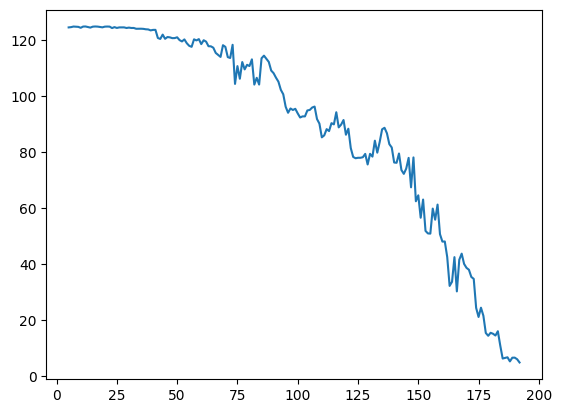

In [6]:
plt.plot(engine_data['time_in_cycles'], engine_y_pred)

In [7]:
# now we continue with the testing section

# loading test data
test_file = "../data/raw/test_FD001.txt"
df_test = pd.read_csv(test_file, sep=r"\s+", header=None)

# assigning the same column names as in training (but WITHOUT RUL)
df_test.columns = columns

print("Test shape:", df_test.shape)
print(df_test.head())
print(df_test['unit_number'].nunique(), "engines in test set")

Test shape: (13096, 26)
   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                 0.0023                 0.0003   
1            1               2                -0.0027                -0.0003   
2            1               3                 0.0003                 0.0001   
3            1               4                 0.0042                 0.0000   
4            1               5                 0.0014                 0.0000   

   operational_setting_3  sensor_measurement_1  sensor_measurement_2  \
0                  100.0                518.67                643.02   
1                  100.0                518.67                641.71   
2                  100.0                518.67                642.46   
3                  100.0                518.67                642.44   
4                  100.0                518.67                642.51   

   sensor_measurement_3  sensor_measurement_4  sensor_measurem

In [8]:
# Temporal Feature Engineering (TEST)

df_test = df_test.sort_values(['unit_number', 'time_in_cycles'])

for sensor in rolling_sensors:
    df_test[f'{sensor}_roll_mean'] = (
        df_test.groupby('unit_number')[sensor]
        .rolling(window_size)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df_test[f'{sensor}_roll_std'] = (
        df_test.groupby('unit_number')[sensor]
        .rolling(window_size)
        .std()
        .reset_index(level=0, drop=True)
    )

for sensor in rolling_sensors:
    df_test[f'{sensor}_roll_slope'] = (
        df_test
        .groupby('unit_number')[sensor]
        .rolling(window_size)
        .apply(rolling_slope, raw=False)
        .reset_index(level=0, drop=True)
    )

for sensor in rolling_sensors:
    df_test[f'{sensor}_delta'] = (
        df_test
        .groupby('unit_number')[sensor]
        .diff()
    )


# drop NaNs from rolling
df_test = df_test.dropna().reset_index(drop=True)

In [9]:
# retrieving last cycle for each engine
df_test_last = df_test.groupby('unit_number').last().reset_index()

print("Test last-cycle shape:", df_test_last.shape)
print(df_test_last.head())

Test last-cycle shape: (100, 46)
   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1              31                -0.0006                 0.0004   
1            2              49                 0.0018                -0.0001   
2            3             126                -0.0016                 0.0004   
3            4             106                 0.0012                 0.0004   
4            5              98                -0.0013                -0.0004   

   operational_setting_3  sensor_measurement_1  sensor_measurement_2  \
0                  100.0                518.67                642.58   
1                  100.0                518.67                642.55   
2                  100.0                518.67                642.88   
3                  100.0                518.67                642.78   
4                  100.0                518.67                642.27   

   sensor_measurement_3  sensor_measurement_4  sensor

In [10]:
# extracting features
X_test = df_test_last[feature_cols]

# scaling using the train scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled test features shape:", X_test_scaled.shape)

Scaled test features shape: (100, 45)


In [11]:
# RUL prediction
y_test_pred = rf.predict(X_test_scaled)

print("Predicted RUL (first 10):")
print(y_test_pred[:10])

Predicted RUL (first 10):
[123.51461089 120.28387004  52.84649802  79.76373617  94.1877286
  92.22028191 108.49958596  85.96194386 119.63679861 108.68105656]


In [12]:
# loading true RUL values
rul_file = "../data/raw/RUL_FD001.txt"
y_test_true = pd.read_csv(rul_file, header=None)[0].values

print("True RUL (first 10):")
print(y_test_true[:10])

True RUL (first 10):
[112  98  69  82  91  93  91  95 111  96]


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae_test = mean_absolute_error(y_test_true, y_test_pred)
r2_test = r2_score(y_test_true, y_test_pred)

print("Test Set Evaluation:")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")
print(f"R²:   {r2_test:.2f}")

Test Set Evaluation:
RMSE: 18.34
MAE:  13.78
R²:   0.81


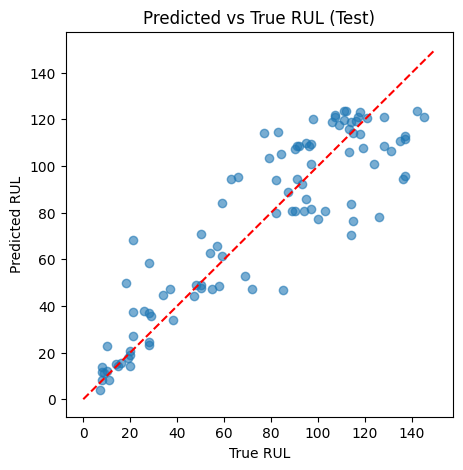

: 

In [ ]:
# using scatter plots

plt.figure(figsize=(5,5))
plt.scatter(y_test_true, y_test_pred, alpha=0.6)
plt.plot([0, 150], [0, 150], 'r--')
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL (Test)")
plt.show()